In [40]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency


In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import pearsonr
from scipy import stats

In [42]:
df = pd.read_csv("amz_uk_price_prediction_dataset.csv")

In [43]:
df.head()

,uid,asin,title,stars,reviews,price,isBestSeller,boughtInLastMonth,category
0,1,B09B96TG33,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
1,2,B01HTH3C8S,"Anker Soundcore mini, Super-Portable Bluetooth...",4.7,98099,23.99,True,0,Hi-Fi Speakers
2,3,B09B8YWXDF,"Echo Dot (5th generation, 2022 release) | Big ...",4.7,15308,21.99,False,0,Hi-Fi Speakers
3,4,B09B8T5VGV,"Echo Dot with clock (5th generation, 2022 rele...",4.7,7205,31.99,False,0,Hi-Fi Speakers
4,5,B09WX6QD65,Introducing Echo Pop | Full sound compact Wi-F...,4.6,1881,17.99,False,0,Hi-Fi Speakers


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2443651 entries, 0 to 2443650
Data columns (total 9 columns):
 #   Column             Dtype  
---  ------             -----  
 0   uid                int64  
 1   asin               str    
 2   title              str    
 3   stars              float64
 4   reviews            int64  
 5   price              float64
 6   isBestSeller       bool   
 7   boughtInLastMonth  int64  
 8   category           str    
dtypes: bool(1), float64(2), int64(3), str(3)
memory usage: 151.5 MB


In [45]:
df.describe()

,uid,stars,reviews,price,boughtInLastMonth
count,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06,2.443651e+06
mean,1.370545e+06,2.152836e+00,4.806278e+02,8.924381e+01,2.589699e+01
std,8.160562e+05,2.194865e+00,5.944124e+03,3.456089e+02,2.404837e+02
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,6.589215e+05,0.000000e+00,0.000000e+00,9.990000e+00,0.000000e+00
50%,1.349029e+06,0.000000e+00,0.000000e+00,1.909000e+01,0.000000e+00
75%,2.060686e+06,4.400000e+00,5.900000e+01,4.599000e+01,0.000000e+00
max,2.828593e+06,5.000000e+00,1.356658e+06,1.000000e+05,5.000000e+04


In [46]:
crosstab = pd.crosstab(df["category"], df["isBestSeller"])

crosstab

isBestSeller,False,True
category,,
3D Printers,247,1
3D Printing & Scanning,4065,2
Abrasive & Finishing Products,245,5
Action Cameras,1696,1
Adapters,251,3
...,...,...
Wind Instruments,243,7
Window Treatments,234,5
Women,17559,213


In [47]:
bestseller_prop = (
    crosstab.div(crosstab.sum(axis=1), axis=0)
)

bestseller_prop.sort_values(True, ascending=False)

isBestSeller,False,True
category,,
Grocery,0.941865,0.058135
Smart Home Security & Lighting,0.942308,0.057692
Health & Personal Care,0.942314,0.057686
Mobile Phone Accessories,0.957529,0.042471
Power & Hand Tools,0.964661,0.035339
...,...,...
Bedding Collections,1.000000,0.000000
CPUs,1.000000,0.000000
"CD, Disc & Tape Players",1.000000,0.000000


In [48]:
chi2, p, dof, expected = chi2_contingency(crosstab)

print("Chi-square:", chi2)
print("P-value:", p)

Chi-square: 36540.20270061387
P-value: 0.0


In [49]:
if p < 0.05:
    print("There is a significant association.")
else:
    print("No significant association.")

There is a significant association.


In [50]:
n = crosstab.sum().sum()

cramers_v = np.sqrt(chi2 / (n * (min(crosstab.shape)-1)))

print("Cramer's V:", cramers_v)

Cramer's V: 0.1222829439760564


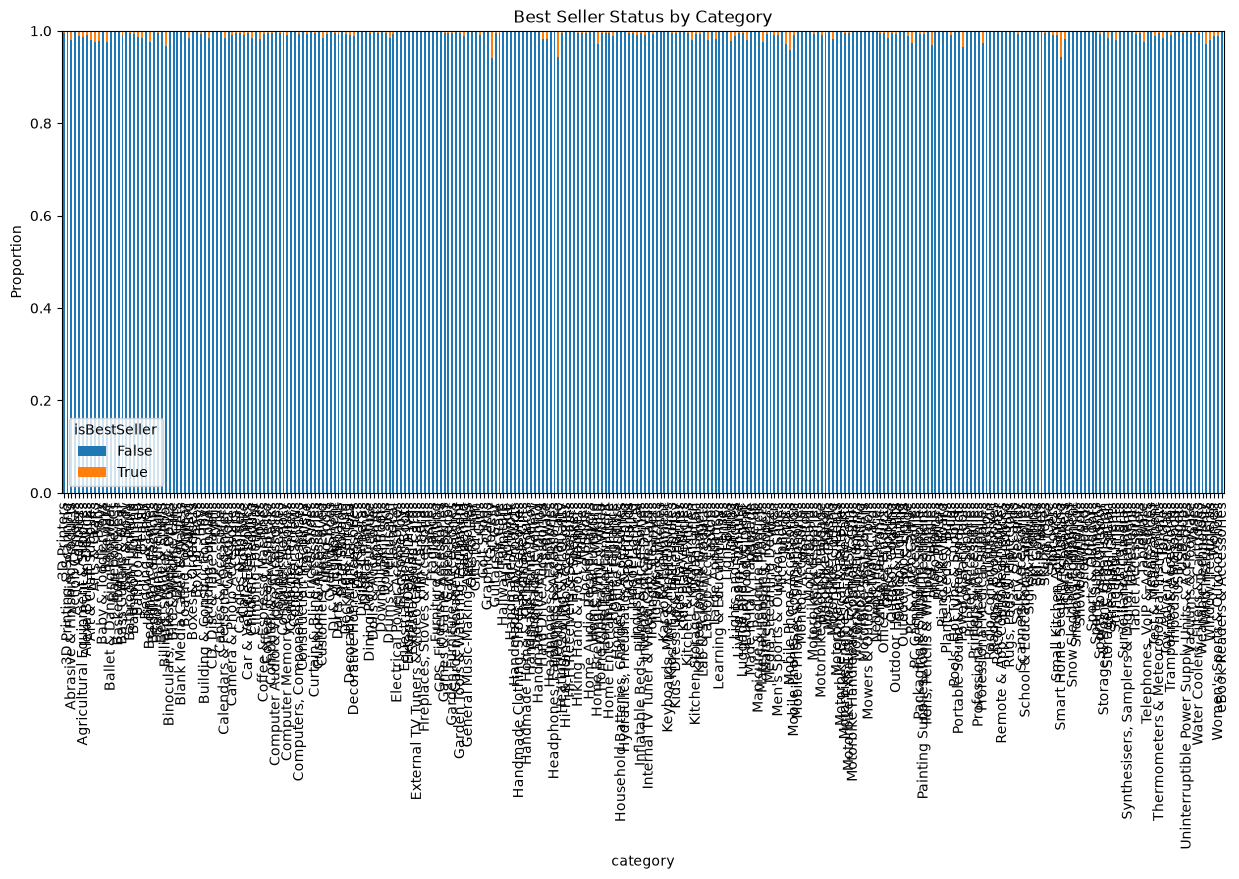

In [51]:
bestseller_prop.plot(
    kind="bar",
    stacked=True,
    figsize=(15,6)
)

plt.ylabel("Proportion")
plt.title("Best Seller Status by Category")
plt.show()

In [52]:
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df_clean = df[
    (df["price"] >= lower) &
    (df["price"] <= upper)
]

In [53]:
top20 = df_clean["category"].value_counts().head(20).index

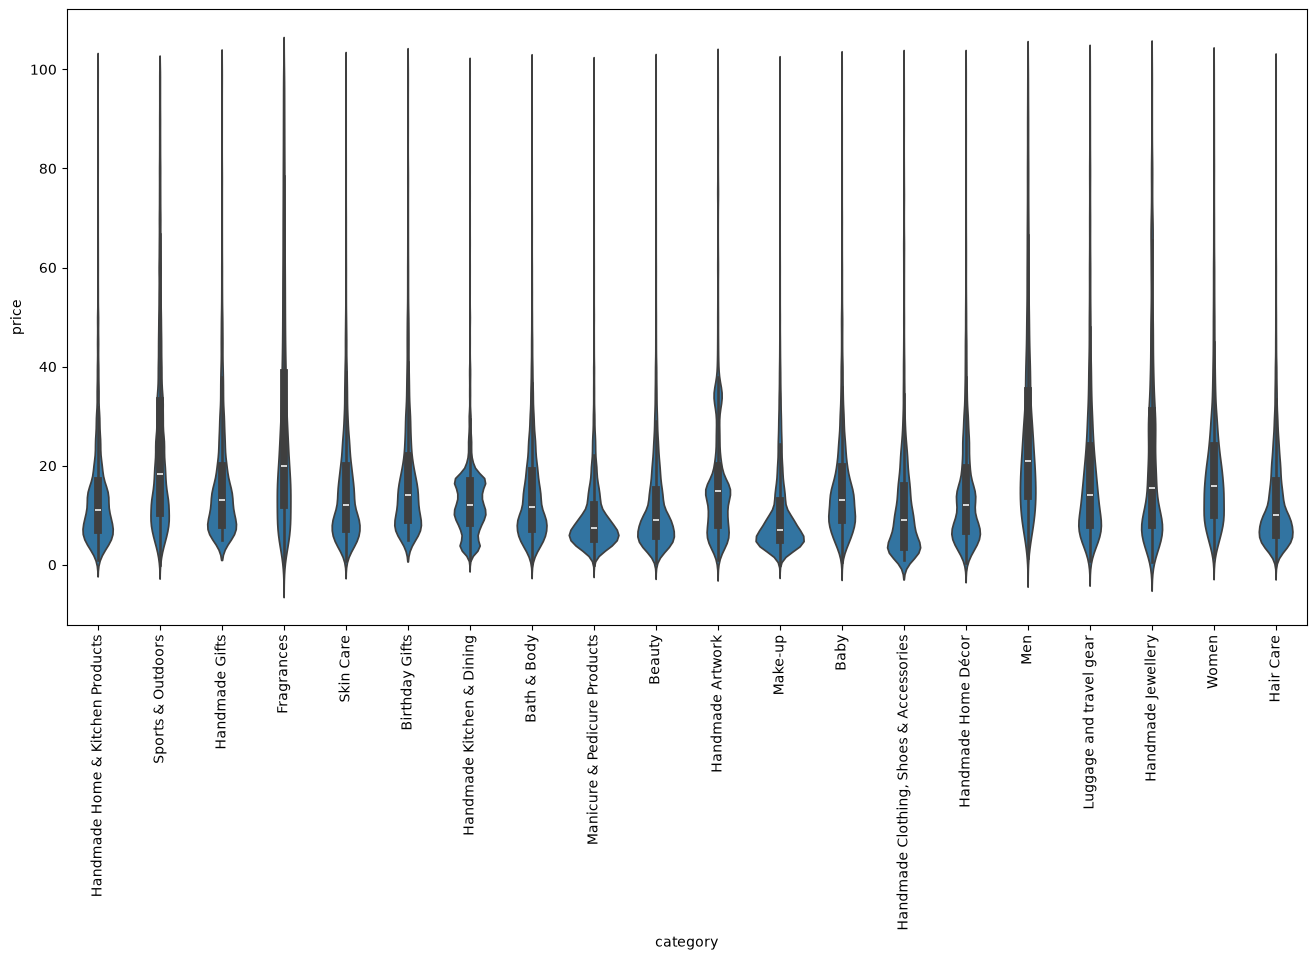

In [54]:
plt.figure(figsize=(16,8))

sns.violinplot(
    data=df_clean[df_clean["category"].isin(top20)],
    x="category",
    y="price"
)

plt.xticks(rotation=90)
plt.show()

In [55]:
df_clean.groupby("category")["price"].median().sort_values(ascending=False)

category
Desktop PCs              74.00
Boxing Shoes             69.79
Tablets                  69.00
Graphics Cards           68.54
Motherboards             67.92
                         ...  
Adapters                  7.05
Make-up                   7.00
Signs & Plaques           6.99
Arts & Crafts             5.99
Office Paper Products     4.37
Name: price, Length: 296, dtype: float64

In [56]:
top10 = df_clean["category"].value_counts().head(10).index

In [57]:
top10 = df_clean["category"].value_counts().head(10).index

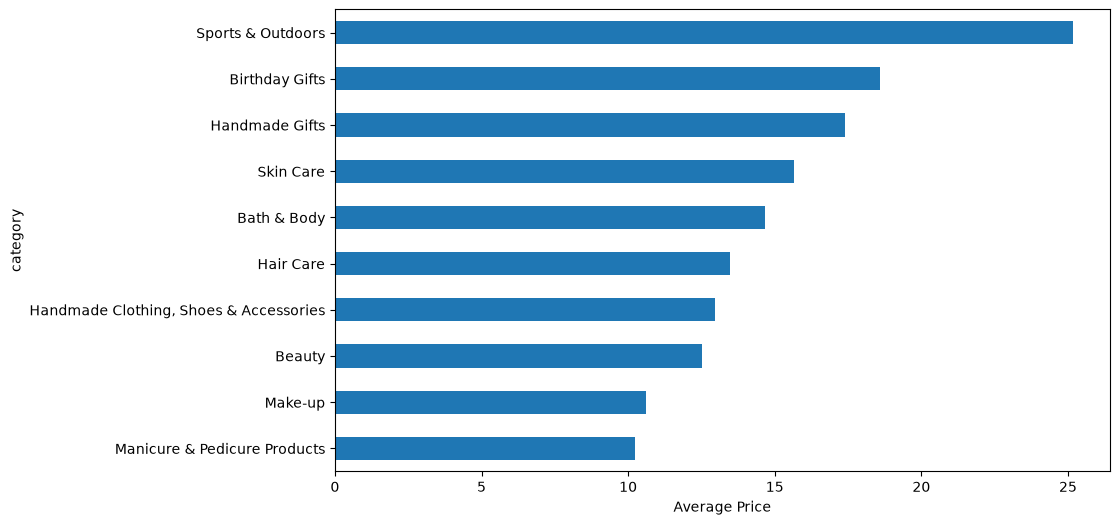

In [58]:
avg_price = (
    df_clean[df_clean["category"].isin(top10)]
    .groupby("category")["price"]
    .mean()
    .sort_values()
)

avg_price.plot(
    kind="barh",
    figsize=(10,6)
)

plt.xlabel("Average Price")
plt.show()

In [59]:
df_clean.groupby("category")["price"].mean().sort_values(ascending=False)

category
Motherboards             68.772432
Boxing Shoes             67.417803
Desktop PCs              66.915562
Tablets                  66.552971
Graphics Cards           65.103509
                           ...    
Bedding Accessories       8.835220
Adapters                  8.750197
Signs & Plaques           8.210513
Arts & Crafts             8.006540
Office Paper Products     6.876369
Name: price, Length: 296, dtype: float64

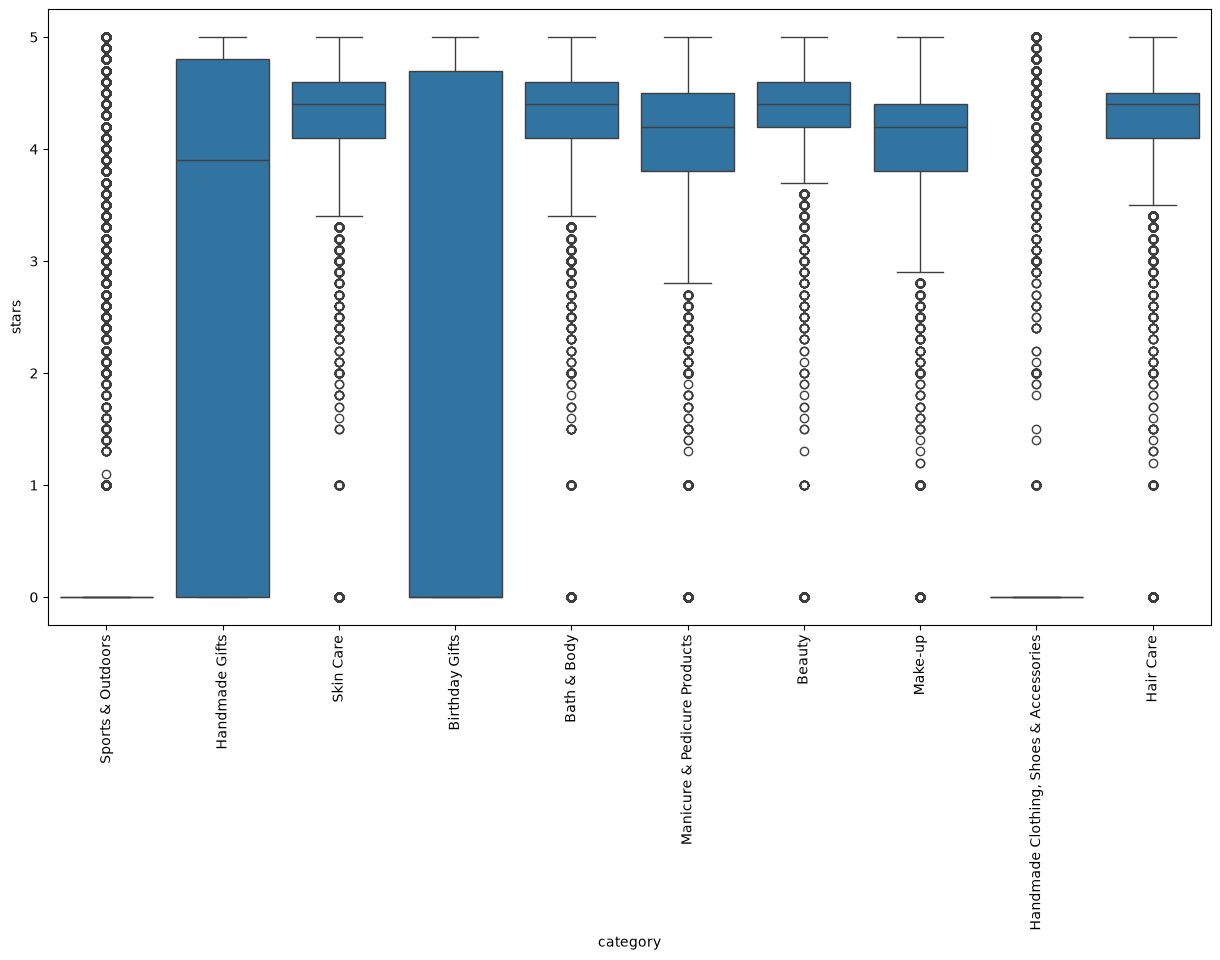

In [60]:
plt.figure(figsize=(15,8))

sns.boxplot(
    data=df_clean[df_clean["category"].isin(top10)],
    x="category",
    y="stars"
)

plt.xticks(rotation=90)
plt.show()

In [61]:
df_clean.groupby("category")["stars"].median().sort_values(ascending=False)

category
Computer Memory                                 4.7
Beer, Wine & Spirits                            4.6
Building & Construction Toys                    4.6
Office Paper Products                           4.6
Kids' Play Figures                              4.6
                                               ... 
Synthesisers, Samplers & Digital Instruments    0.0
Tablets                                         0.0
Action Cameras                                  0.0
3D Printing & Scanning                          0.0
eBook Readers & Accessories                     0.0
Name: stars, Length: 296, dtype: float64

In [62]:
corr = df_clean["price"].corr(df_clean["stars"])

print(corr)

-0.07767299878181444


In [63]:
r, p = pearsonr(df_clean["price"], df_clean["stars"])

print(r)
print(p)

-0.07767299878181332
0.0


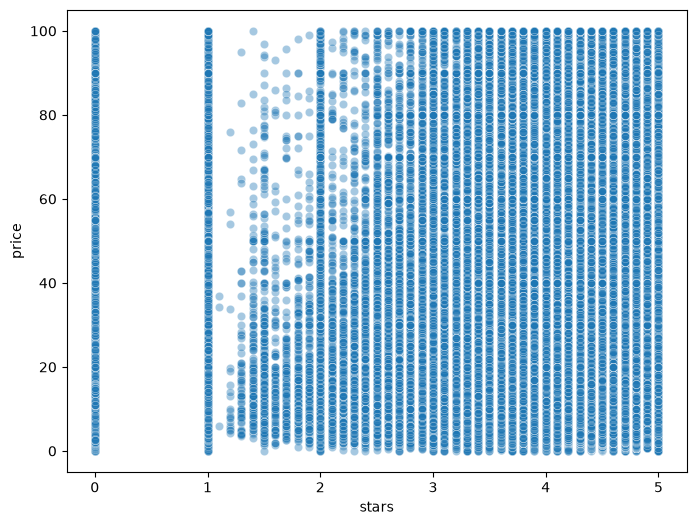

In [64]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x="stars",
    y="price",
    alpha=0.4
)

plt.show()

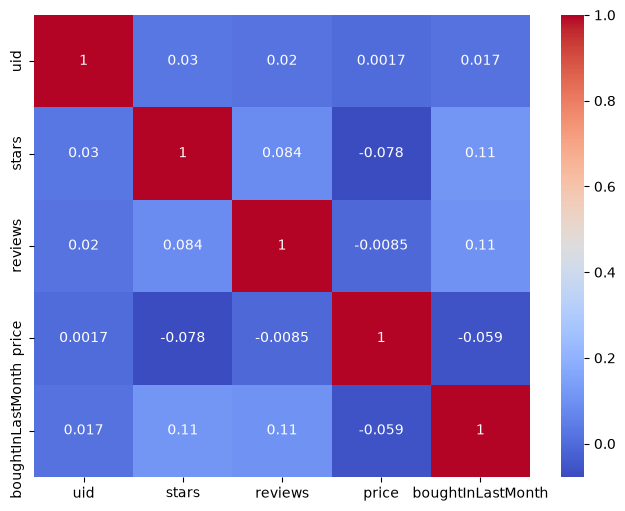

In [65]:
numeric = df_clean.select_dtypes(include=np.number)

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.show()

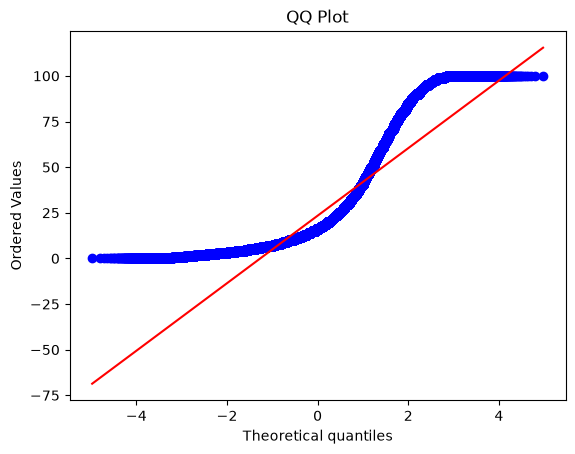

In [66]:
stats.probplot(df_clean["price"], dist="norm", plot=plt)

plt.title("QQ Plot")
plt.show()

The Chi-square test suggests that bestseller status depends on product category. However, Cramer's V indicates that the association is weak/moderate, meaning category influences bestseller status but is not the only factor.

Price distributions differ substantially across categories. Premium categories have much higher median and average prices, while most categories contain lower-priced products.

The correlation between price and ratings is weak, indicating that expensive products are not necessarily rated more highly by customers.

df = df.dropna(subset=["category", "price", "stars", "isBestSeller"])